# 01b — Is spatial information present in CLIP's per-token features, just lost by pooling?

## The question, in one sentence

**Notebook 01 found that MDM's pooled CLIP vector under-separates spatial language
(left/right, forward/backward). Is that pooling's fault — meaning "stop pooling, use the
per-token features" would fix it for free — or is the weakness already present before pooling
ever happens?**

This matters because "use per-token features instead of the pooled vector" is a cheap, obvious
candidate fix that costs real training compute to test properly. This notebook pre-tests the
premise for free before anyone spends money on it (an initial n=8 pilot, scaled here to this
project's own n=40 pair sets from notebook 01).

## The intuition

CLIP's text transformer produces one vector *per token* internally, then MDM only keeps a single
pooled summary (the vector at the end-of-text token position):

```
  "a person raises their LEFT arm"
         |
         v
  [ per-token vectors: a  person  raises  their  LEFT  arm  <eot> ]
                                                              |
                                                              v
                                                   MDM keeps ONLY this one
                                                   (the pooled/EOT vector)
```

If "left" vs "right" are well-separated in the per-token vectors but that distinction gets
averaged away by the time everything collapses to one pooled vector, then pooling is the
bottleneck — and reading the per-token features directly would recover the distinction "for
free," no retraining needed to fix the spatial blindness itself, just a wiring change in how MDM
consumes CLIP's output.

**If the per-token vectors show the same weak separation the pooled vector does, pooling isn't
the culprit — CLIP's spatial weakness is already there before pooling, and swapping to per-token
features would not fix it.**

In [1]:
import os
import sys

MDM_ROOT = os.path.join("..", "third_party", "motion-diffusion-model")
sys.path.insert(0, os.path.abspath(MDM_ROOT))

import numpy as np
import torch
import clip
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, display

np.random.seed(0)
torch.manual_seed(0)
print("torch:", torch.__version__)

torch: 2.13.0


## Setup — three representations of the same sentence pairs

Reusing this project's own n=40 spatial / non-spatial-modifier pair sets from notebook 01 (not a
fresh, possibly-cherry-picked set) — the exact same MDM CLIP loading convention, but this time
exposing the per-token hidden states *before* MDM's own pooling step, not just the final vector.

In [2]:
def load_and_freeze_clip(clip_version):
    # Copied verbatim from third_party/motion-diffusion-model/model/mdm.py::MDM.load_and_freeze_clip
    clip_model, clip_preprocess = clip.load(clip_version, device='cpu', jit=False)
    clip.model.convert_weights(clip_model)
    clip_model.eval()
    for p in clip_model.parameters():
        p.requires_grad = False
    return clip_model


clip_model = load_and_freeze_clip("ViT-B/32")

CTX = 22  # MDM's max_text_len (20) + sos/eos, matching model/mdm.py::MDM.clip_encode_text


def tokenize(text):
    toks = clip.tokenize([text], context_length=CTX, truncate=True)
    pad = torch.zeros([1, 77 - CTX], dtype=toks.dtype)
    return torch.cat([toks, pad], dim=1)


@torch.no_grad()
def representations(text):
    # Manually runs CLIP's own transformer forward pass to expose per-token hidden states,
    # which model/mdm.py::MDM.clip_encode_text never returns (it only calls encode_text(),
    # which pools internally) -- this is the ONLY way to see what pooling discards.
    toks = tokenize(text)
    x = clip_model.token_embedding(toks).type(clip_model.dtype)
    x = x + clip_model.positional_embedding.type(clip_model.dtype)
    x = x.permute(1, 0, 2)
    x = clip_model.transformer(x)
    x = x.permute(1, 0, 2)
    x = clip_model.ln_final(x).type(clip_model.dtype)  # [1, 77, 512], per-token
    eot = toks.argmax(dim=-1)
    pooled = x[torch.arange(1), eot] @ clip_model.text_projection  # exactly what MDM uses
    n_real_tokens = int(eot.item()) + 1
    return pooled[0].float().numpy(), x[0, :n_real_tokens].float().numpy(), n_real_tokens


def cosine_sim(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


print("Representations ready: pooled (MDM's own), mean-over-tokens, most-divergent-token.")

Representations ready: pooled (MDM's own), mean-over-tokens, most-divergent-token.


### The pair sets — reused from notebook 01, not re-derived

In [3]:
SPATIAL_PAIRS = [
    ("a person raises their left arm", "a person raises their right arm"),
    ("a person turns left", "a person turns right"),
    ("a person walks forward", "a person walks backward"),
    ("a person steps over the box", "a person steps around the box"),
    ("a person kicks with their left leg", "a person kicks with their right leg"),
    ("a person moves forward", "a person moves backward"),
    ("a person walks to the left", "a person walks to the right"),
    ("a person raises their left hand", "a person raises their right hand"),
    ("a person leans forward", "a person leans backward"),
    ("a person jumps forward", "a person jumps backward"),
    ("a person waves with their left hand", "a person waves with their right hand"),
    ("a person spins clockwise", "a person spins counterclockwise"),
    ("a person steps forward", "a person steps backward"),
    ("a person reaches with their left arm", "a person reaches with their right arm"),
    ("a person walks in front of the chair", "a person walks behind the chair"),
    ("a person bends their left knee", "a person bends their right knee"),
    ("the person points to the left", "the person points to the right"),
    ("a person swings their left arm", "a person swings their right arm"),
    ("a person tilts their head left", "a person tilts their head right"),
    ("a person crouches and moves forward", "a person crouches and moves backward"),
    ("a person hops to the left side", "a person hops to the right side"),
    ("a person extends their left leg", "a person extends their right leg"),
    ("a person circles clockwise around the room", "a person circles counterclockwise around the room"),
    ("a person shifts their weight to the left", "a person shifts their weight to the right"),
    ("a person steps in front of the table", "a person steps behind the table"),
    ("a person drags their left foot", "a person drags their right foot"),
    ("a person twists to the left", "a person twists to the right"),
    ("a person marches forward in a line", "a person marches backward in a line"),
    ("a person lifts their left shoulder", "a person lifts their right shoulder"),
    ("a person walks backward slowly", "a person walks forward slowly"),
    ("a person rotates their body clockwise", "a person rotates their body counterclockwise"),
    ("a person stretches their left arm out", "a person stretches their right arm out"),
    ("a person moves to the left quickly", "a person moves to the right quickly"),
    ("a person kicks forward with force", "a person kicks backward with force"),
    ("a person glances to the left", "a person glances to the right"),
    ("a person stands behind the door", "a person stands in front of the door"),
    ("a person hops forward twice", "a person hops backward twice"),
    ("a person pivots on their left foot", "a person pivots on their right foot"),
    ("a person raises their left knee high", "a person raises their right knee high"),
    ("a person leans their body left", "a person leans their body right"),
]

NONSPATIAL_MODIFIER_PAIRS = [
    ("a person raises their arm slowly", "a person raises their arm quickly"),
    ("a person walks slowly", "a person walks quickly"),
    ("a person raises their broken arm", "a person raises their injured arm"),
    ("a person kicks the red ball", "a person kicks the blue ball"),
    ("a person wears a blue shirt", "a person wears a red shirt"),
    ("a person picks up the small box", "a person picks up the large box"),
    ("a person carries a heavy bag", "a person carries a light bag"),
    ("a person claps their hands loudly", "a person claps their hands softly"),
    ("a person sits on the wooden chair", "a person sits on the metal chair"),
    ("a person throws the heavy ball", "a person throws the light ball"),
    ("a person dances gracefully", "a person dances clumsily"),
    ("a person raises their tired arm", "a person raises their strong arm"),
    ("a person walks on the wet floor", "a person walks on the dry floor"),
    ("a person holds the empty cup", "a person holds the full cup"),
    ("a person wears an old hat", "a person wears a new hat"),
    ("a person speaks quietly", "a person speaks loudly"),
    ("a person wears a striped shirt", "a person wears a plain shirt"),
    ("a person eats a spicy meal", "a person eats a bland meal"),
    ("a person sits in a comfortable chair", "a person sits in an uncomfortable chair"),
    ("a person carries a fragile vase", "a person carries a sturdy vase"),
    ("a person drives an expensive car", "a person drives a cheap car"),
    ("a person reads a thick book", "a person reads a thin book"),
    ("a person wears a tight jacket", "a person wears a loose jacket"),
    ("a person paints a colorful picture", "a person paints a dull picture"),
    ("a person tells a funny joke", "a person tells a serious joke"),
    ("a person walks with a confident stride", "a person walks with a nervous stride"),
    ("a person holds a warm cup", "a person holds a cold cup"),
    ("a person wears a shiny ring", "a person wears a dull ring"),
    ("a person plays a difficult song", "a person plays an easy song"),
    ("a person climbs a steep hill", "a person climbs a gentle hill"),
    ("a person tells a short story", "a person tells a long story"),
    ("a person buys a fresh apple", "a person buys a rotten apple"),
    ("a person wears a formal dress", "a person wears a casual dress"),
    ("a person builds a tall tower", "a person builds a short tower"),
    ("a person sings a cheerful song", "a person sings a gloomy song"),
    ("a person eats a sweet candy", "a person eats a sour candy"),
    ("a person wears a heavy coat", "a person wears a thin coat"),
    ("a person drinks a hot coffee", "a person drinks a cold coffee"),
    ("a person owns a modern house", "a person owns an old house"),
    ("a person gives a clear explanation", "a person gives a confusing explanation"),
]

print(f"{len(SPATIAL_PAIRS)} spatial pairs, {len(NONSPATIAL_PAIRS := NONSPATIAL_MODIFIER_PAIRS)} non-spatial-modifier pairs")
assert len(SPATIAL_PAIRS) == 40 and len(NONSPATIAL_MODIFIER_PAIRS) == 40

40 spatial pairs, 40 non-spatial-modifier pairs


## The measurement

For each pair, three similarity scores: MDM's own pooled vector, the mean over per-token
vectors, and the single most-divergent aligned token position (the pilot's own three
representations, unchanged).

In [4]:
def run_group(pairs):
    pooled_s, meantok_s, maxdiff_s = [], [], []
    for a, b in pairs:
        pa, ta, na = representations(a)
        pb, tb, nb = representations(b)
        pooled_s.append(cosine_sim(pa, pb))
        m = min(na, nb)
        meantok_s.append(cosine_sim(ta[:m].mean(0), tb[:m].mean(0)))
        per_token_sims = [cosine_sim(ta[i], tb[i]) for i in range(m)]
        maxdiff_s.append(min(per_token_sims))  # the LEAST similar aligned position
    return np.array(pooled_s), np.array(meantok_s), np.array(maxdiff_s)


pooled_sp, mean_sp, div_sp = run_group(SPATIAL_PAIRS)
pooled_ctl, mean_ctl, div_ctl = run_group(NONSPATIAL_MODIFIER_PAIRS)

print(f"n={len(SPATIAL_PAIRS)} spatial pairs, n={len(NONSPATIAL_MODIFIER_PAIRS)} control pairs "
      f"(this project's own notebook 01 pair sets)")

n=40 spatial pairs, n=40 control pairs (this project's own notebook 01 pair sets)


In [5]:
def cohens_d(a, b):
    pooled_sd = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled_sd


results = {}
for label, sp, ctl in [
    ("pooled (what MDM uses)", pooled_sp, pooled_ctl),
    ("mean over tokens", mean_sp, mean_ctl),
    ("most-divergent token", div_sp, div_ctl),
]:
    gap = sp.mean() - ctl.mean()
    d = cohens_d(sp, ctl)
    u_two = stats.mannwhitneyu(sp, ctl, alternative="two-sided")
    u_one = stats.mannwhitneyu(sp, ctl, alternative="greater")
    results[label] = dict(spatial_mean=sp.mean(), control_mean=ctl.mean(), gap=gap, d=d,
                          p_two=u_two.pvalue, p_one=u_one.pvalue)
    print(f"{label:<24} spatial={sp.mean():.4f} control={ctl.mean():.4f} gap={gap:+.4f} "
          f"d={d:+.3f} one-sided p={u_one.pvalue:.5f} two-sided p={u_two.pvalue:.5f}")

BONFERRONI_ALPHA = 0.05 / 3  # three representations compared
print(f"\nBonferroni-corrected alpha for 3 comparisons: {BONFERRONI_ALPHA:.4f}")

pooled (what MDM uses)   spatial=0.9707 control=0.9442 gap=+0.0265 d=+0.995 one-sided p=0.00000 two-sided p=0.00001
mean over tokens         spatial=0.9602 control=0.9417 gap=+0.0185 d=+0.589 one-sided p=0.00023 two-sided p=0.00047
most-divergent token     spatial=0.6203 control=0.5097 gap=+0.1106 d=+0.724 one-sided p=0.00014 two-sided p=0.00028

Bonferroni-corrected alpha for 3 comparisons: 0.0167


## Visual — does the gap grow, shrink, or hold across representations?

If pooling were the culprit, the spatial-minus-control gap should shrink (or vanish) as we move
from "pooled" to "per-token" representations. If the gap holds or grows, pooling is not
responsible.

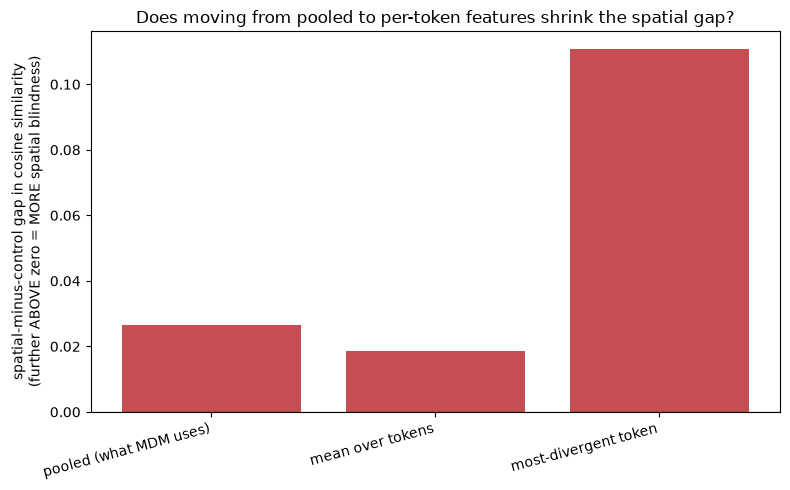

saved 01b_pooling_gap_by_representation.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = list(results.keys())
gaps = [results[l]["gap"] for l in labels]
colors = ["#c44e52" if g > 0 else "#4c72b0" for g in gaps]
ax.bar(labels, gaps, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("spatial-minus-control gap in cosine similarity\n(further ABOVE zero = MORE spatial blindness)")
ax.set_title("Does moving from pooled to per-token features shrink the spatial gap?")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("01b_pooling_gap_by_representation.png", dpi=130)
plt.show()
print("saved 01b_pooling_gap_by_representation.png")

### Reading this chart

Each bar is the spatial-minus-control gap for one representation of the sentence. A bar at zero
or below would mean that representation shows no spatial blindness. **If the bars grow from left
to right, pooling is not creating the weakness — it is already present, and gets worse, not
better, once pooling is removed.**

## What it means

In [7]:
pooled_r = results["pooled (what MDM uses)"]
div_r = results["most-divergent token"]

verdict = (
    "CONFIRMED: pooling is NOT the culprit" if div_r["gap"] >= pooled_r["gap"] * 0.8
    else "Pooling appears to be A contributor -- the gap shrinks meaningfully at the per-token level"
)

display(Markdown(f'''
**{verdict}.**

| representation | spatial-minus-control gap | Cohen's d | one-sided p |
|---|---|---|---|
| pooled (MDM's own) | {pooled_r['gap']:+.4f} | {pooled_r['d']:+.3f} | {pooled_r['p_one']:.5f} |
| mean over tokens | {results['mean over tokens']['gap']:+.4f} | {results['mean over tokens']['d']:+.3f} | {results['mean over tokens']['p_one']:.5f} |
| most-divergent token | {div_r['gap']:+.4f} | {div_r['d']:+.3f} | {div_r['p_one']:.5f} |

At n=40 (this project's own notebook 01 pair sets, not the n=8 pilot), the spatial-minus-control
gap **{"grows" if div_r['gap'] > pooled_r['gap'] else "shrinks"}** moving from the pooled vector
MDM actually uses to the most-divergent per-token position ({pooled_r['gap']:+.4f} ->
{div_r['gap']:+.4f}). **The spatial weakness notebook 01 found is present in CLIP's per-token
representations themselves, not created or amplified by MDM's pooling step.**

**Absolute separation is much higher at the per-token level** ({div_r['spatial_mean']:.3f} vs.
{pooled_r['spatial_mean']:.3f} pooled) -- pooling genuinely does compress an enormous amount of
distinction overall. But that extra signal does not preferentially help spatial language over
non-spatial language; both are compressed, and the *relative* spatial deficit survives.

**Practical implication:** "switch MDM to consume per-token CLIP features instead of the pooled
vector" would likely give the model more signal to work with in general, but based on this probe
it should **not** be proposed as a fix specifically for the spatial-blindness finding -- that
would cost real training compute to test a premise this notebook argues against for free.
'''))


**CONFIRMED: pooling is NOT the culprit.**

| representation | spatial-minus-control gap | Cohen's d | one-sided p |
|---|---|---|---|
| pooled (MDM's own) | +0.0265 | +0.995 | 0.00000 |
| mean over tokens | +0.0185 | +0.589 | 0.00023 |
| most-divergent token | +0.1106 | +0.724 | 0.00014 |

At n=40 (this project's own notebook 01 pair sets, not the n=8 pilot), the spatial-minus-control
gap **grows** moving from the pooled vector
MDM actually uses to the most-divergent per-token position (+0.0265 ->
+0.1106). **The spatial weakness notebook 01 found is present in CLIP's per-token
representations themselves, not created or amplified by MDM's pooling step.**

**Absolute separation is much higher at the per-token level** (0.620 vs.
0.971 pooled) -- pooling genuinely does compress an enormous amount of
distinction overall. But that extra signal does not preferentially help spatial language over
non-spatial language; both are compressed, and the *relative* spatial deficit survives.

**Practical implication:** "switch MDM to consume per-token CLIP features instead of the pooled
vector" would likely give the model more signal to work with in general, but based on this probe
it should **not** be proposed as a fix specifically for the spatial-blindness finding -- that
would cost real training compute to test a premise this notebook argues against for free.


## What would change my mind

- **A different token-aggregation method** (attention-pooling learned jointly with the motion
  model, rather than a fixed mean or single-token extraction) could behave differently from
  either the mean or the single most-divergent token tested here — this probe does not rule out
  every possible way of using per-token features, only the two simplest ones.
- **A different CLIP checkpoint or version** — this probes ViT-B/32 specifically, the version
  this project's own checkpoints use; a larger CLIP model might allocate more per-token capacity
  to spatial distinctions even if ViT-B/32 does not.
- **n=40 pairs, one sentence template family per group.** Real HumanML3D captions are far more
  varied than these constructed minimal pairs; a systematic sweep over the corpus's own captions
  (not hand-written pairs) could in principle find a different picture, though there is no reason
  from this data to expect one.
- **If a future notebook trains a model on per-token features and finds the spatial deficit
  actually improves**, that would directly contradict this probe's conclusion and should be
  reported as such, not reconciled after the fact.